In [14]:
!pip install pandas

## RevIN, PatchTSTLayer, PredHead + training_step

In [15]:
import torch
import torch.nn as nn
import lightning as L
from einops import rearrange

In [16]:
class RevIN(nn.Module):
    def __init__(self, n_channels, eps=1e-5, affine=True):
        super(RevIN, self).__init__()
        self.num_features = n_channels
        self.eps = eps
        self.affine = affine
        if self.affine:
            self._init_params()

    def forward(self, x, mode: str):
        if mode == "norm":
            self._get_statistics(x)
            x = self._normalize(x)
        elif mode == "denorm":
            x = self._denormalize(x)
        else:
            raise NotImplementedError
        return x

    def _init_params(self):
        self.affine_weight = nn.Parameter(torch.ones(self.num_features))
        self.affine_bias = nn.Parameter(torch.zeros(self.num_features))

    def _get_statistics(self, x):
        self.mean = x.mean(dim=1, keepdim=True).detach()
        self.stdev = torch.sqrt(x.var(dim=1, keepdim=True, unbiased=False) + self.eps).detach()

    def _normalize(self, x):
        x = (x - self.mean) / self.stdev
        if self.affine:
            x = x * self.affine_weight + self.affine_bias
        return x

    def _denormalize(self, x):
        if self.affine:
            x = x - self.affine_bias
            x = x / (self.affine_weight + self.eps * self.eps)
        x = x * self.stdev + self.mean
        return x

In [17]:
class PatchTSTLayer(nn.Module):
    def __init__(self, d_model, n_head, ffn_ratio: int = 2, dropout=0.0):
        super().__init__()
        self.mha = nn.MultiheadAttention(
            d_model, n_head, batch_first=True, dropout=dropout
        )
        self.ln1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_ratio * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_ratio * d_model, d_model),
            nn.Dropout(dropout),
        )
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x):
        tmp, _ = self.mha(x, x, x)
        x = self.ln1(x + tmp)
        tmp = self.ffn(x)
        x = self.ln2(x + tmp)

        return x

In [18]:
class PredHead(nn.Module):
    def __init__(self, patch_num, d_model, pred_len, dropout=0.0):
        super().__init__()
        self.linear = nn.Linear(patch_num * d_model, pred_len)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.linear(x)
        x = self.dropout(x)
        return x

In [19]:
class PatchTST(L.LightningModule):
    def __init__(
        self,
        n_channels,
        d_model=128,
        n_head=16,
        n_layer=3,
        dropout=0.0,
        input_len=336,
        patch_len=16,
        strides=8,
        pred_len=96,
    ):
        super().__init__()
        self.input_len = input_len
        self.patch_len = patch_len
        self.strides = strides
        self.pred_len = pred_len

        self.revin = RevIN(n_channels)

        self.padding_patch_layer = nn.ReplicationPad1d((0, strides))

        self.n_patches = (input_len - patch_len) // strides + 2

        self.tokenizer = nn.Linear(patch_len, d_model)
        self.pe = nn.Parameter(torch.randn((self.n_patches, d_model)))
        self.encs = nn.ModuleList(
            [PatchTSTLayer(d_model, n_head, dropout=dropout) for _ in range(n_layer)]
        )
        
        self.pred_head = PredHead(self.n_patches, d_model, pred_len, dropout)

        self.save_hyperparameters()

    def forward(self, x):
        bs, seq_len, n_channels = x.shape
        x = self.revin(x, mode="norm")
        x = rearrange(x, "b l c -> b c l")
        x = self.padding_patch_layer(x)
        x = x.unfold(dimension=-1, size=self.patch_len, step=self.strides)
        x = self.tokenizer(x)
        x = x + self.pe[None, None, :, :]
        x = rearrange(x, "b c np d_model -> (b c) np d_model")
        for enc in self.encs:
            x = enc(x)

        x = rearrange(x, "(b c) np d_model -> (b c) (np d_model)", b=bs, c=n_channels)
        x = self.pred_head(x)

        x = rearrange(x, "(b c) pl -> b pl c", b=bs, c=n_channels)
        x = self.revin(x, mode="denorm")

        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = nn.functional.mse_loss(y_hat, y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = nn.functional.mse_loss(y_hat, y)
        self.log("val_loss", loss)

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        mse = nn.functional.mse_loss(y_hat, y)
        mae = nn.functional.l1_loss(y_hat, y)
        self.log("test_mse", mse)
        self.log("test_mae", mae)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-4)

# PatchTST 성능 평가

In [20]:
# ETTh1 (전력 변압기 온도) 데이터셋
import pandas as pd
import numpy as np

# 공식 저장소에서 바로 불러오기
url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
df = pd.read_csv(url)

print(df.shape)
print(df.head())

(17420, 8)
                  date   HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
0  2016-07-01 00:00:00  5.827  2.009  1.599  0.462  4.203  1.340  30.531000
1  2016-07-01 01:00:00  5.693  2.076  1.492  0.426  4.142  1.371  27.787001
2  2016-07-01 02:00:00  5.157  1.741  1.279  0.355  3.777  1.218  27.787001
3  2016-07-01 03:00:00  5.090  1.942  1.279  0.391  3.807  1.279  25.044001
4  2016-07-01 04:00:00  5.358  1.942  1.492  0.462  3.868  1.279  21.948000


In [21]:
raw_data = df.drop(columns=["date"]).values.astype(np.float32)
print(raw_data.shape)  

(17420, 7)


In [23]:
from torch.utils.data import Dataset, DataLoader

class TSDataset(Dataset):
    def __init__(self, data, input_len, pred_len):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.input_len = input_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.input_len - self.pred_len + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.input_len]
        y = self.data[idx + self.input_len : idx + self.input_len + self.pred_len]
        return x, y

In [24]:
train_ratio, val_ratio = 0.7, 0.1

input_len = 336
pred_len = 96

n = len(raw_data)
train_data = raw_data[: int(n * train_ratio)]
val_data   = raw_data[int(n * train_ratio) - input_len : int(n * (train_ratio + val_ratio))]
test_data  = raw_data[int(n * (train_ratio + val_ratio)) - input_len :]

print("train:", train_data.shape)
print("val:  ", val_data.shape)
print("test: ", test_data.shape)

mean = train_data.mean(axis=0, keepdims=True)
std = train_data.std(axis=0, keepdims=True) + 1e-8

train_data = (train_data - mean) / std
val_data   = (val_data - mean) / std
test_data  = (test_data - mean) / std

train_dataset = TSDataset(train_data, input_len, pred_len)
val_dataset   = TSDataset(val_data, input_len, pred_len)
test_dataset  = TSDataset(test_data, input_len, pred_len)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(len(train_dataset), len(val_dataset), len(test_dataset))

train: (12194, 7)
val:   (2077, 7)
test:  (3821, 7)
11763 1646 3390


In [25]:
model = PatchTST(
    n_channels=7,
    d_model=128,
    n_head=16,
    n_layer=3,
    input_len=input_len,
    patch_len=16,
    strides=8,
    pred_len=pred_len,
)

trainer = L.Trainer(
    max_epochs=30,
    accelerator="gpu",   
    devices=1,
    callbacks=[
        L.pytorch.callbacks.EarlyStopping(monitor="val_loss", patience=5),
    ],
)

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
c:\Users\ekgus\anaconda3\envs\diffusion-study\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\ekgus\anaconda3\envs\diffusion-study\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\ekgus\anaconda3\envs\diffusion-study\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [27]:
# 1. 테스트셋 최종 성능
trainer.test(model, dataloaders=test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\ekgus\anaconda3\envs\diffusion-study\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_mae            0.45286551117897034
        test_mse            0.4205564260482788
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_mse': 0.4205564260482788, 'test_mae': 0.45286551117897034}]

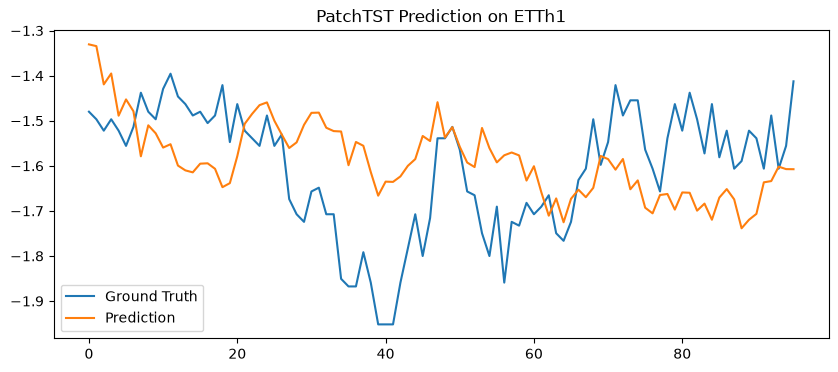

In [29]:
import matplotlib.pyplot as plt

model.eval()
model = model.cuda()   

x, y = next(iter(test_loader))
x, y = x.cuda(), y.cuda()

with torch.no_grad():
    y_hat = model(x)

ch = 6  # OT(오일 온도) 채널 확인
plt.figure(figsize=(10,4))
plt.plot(y[0, :, ch].cpu(), label="Ground Truth")
plt.plot(y_hat[0, :, ch].cpu(), label="Prediction")
plt.legend()
plt.title("PatchTST Prediction on ETTh1")
plt.show()